<div style="text-align: center; padding: 18px 0;">
  <h1 style="color: #16324f; margin-bottom: 8px;">
    Stratégie long-short momentum-value sur les actions Européennes
  </h1>
  <h3 style="color: #5c6770; margin-top: 0;">
    Data-Analyse des performances
  </h3>
  <p style="color: #8a8f98; font-size: 15px;">
    Projet de finance de marché • Python • Analyse quantitative
  </p>
</div>


## Objectif du notebook

Ce notebook a pour but de proposer une vraie **data analyse** de la stratégie long-short construite dans `Strategie_long_short.ipynb`.

On cherche ici à répondre visuellement à plusieurs questions :

- quelle est la dynamique de performance de la stratégie au cours du temps ;
- quelle est la contribution relative des jambes long et short ;
- à quoi ressemble la distribution des rendements mensuels ;
- la stratégie fait-elle mieux qu'une approche aléatoire de type *lucky* ;
- quelles actions apparaissent le plus souvent dans les portefeuilles.

Les graphiques sont volontairement produits uniquement avec `matplotlib` pour rester cohérents avec le reste du projet.

In [24]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "02_Strategie_long_short").exists() and PROJECT_ROOT.name == "02_Strategie_long_short":
    PROJECT_ROOT = PROJECT_ROOT.parent

CANDIDATS_DONNEES = [
    PROJECT_ROOT / "02_Strategie_long_short" / "02_Strategie_long_short" / "data",
    PROJECT_ROOT / "02_Strategie_long_short" / "data",
]
DOSSIER_DONNEES = next((path for path in CANDIDATS_DONNEES if path.exists()), None)
if DOSSIER_DONNEES is None:
    raise FileNotFoundError("Impossible de trouver le dossier data du projet strategie long-short.")

performances = pd.read_csv(
    DOSSIER_DONNEES / "performances_mensuelles_strategie.csv",
    parse_dates=["date_formation", "date_performance"],
)
rendements_univers = pd.read_csv(DOSSIER_DONNEES / "rendements_mensuels_europe.csv", parse_dates=["date"])
ponderations = pd.read_csv(DOSSIER_DONNEES / "ponderations_etape3.csv", parse_dates=["date"])
selection = pd.read_csv(DOSSIER_DONNEES / "selection_etape2.csv", parse_dates=["date"])
evaluation_lucky = pd.read_csv(DOSSIER_DONNEES / "evaluation_strategie_vs_lucky.csv")
lucky_stats = pd.read_csv(DOSSIER_DONNEES / "performances_lucky_stats.csv")
lucky_detail = pd.read_csv(
    DOSSIER_DONNEES / "performances_lucky_detail.csv",
    parse_dates=["date_formation", "date_performance"],
)
scores = pd.read_csv(DOSSIER_DONNEES / "scores_etape1.csv", parse_dates=["date"])
statistiques_strategie = pd.read_csv(DOSSIER_DONNEES / "statistiques_strategie.csv")

performances = performances.sort_values("date_performance").reset_index(drop=True)
rendements_univers = rendements_univers.sort_values("date").set_index("date")
performances["wealth_strategie"] = (1 + performances["performance_strategie"]).cumprod()
performances["wealth_long"] = (1 + performances["performance_long"]).cumprod()
performances["wealth_short"] = (1 + performances["performance_short"]).cumprod()
performances["drawdown_strategie"] = performances["wealth_strategie"] / performances["wealth_strategie"].cummax() - 1
performances["rolling_vol_6m"] = performances["performance_strategie"].rolling(6).std(ddof=0)
performances["rolling_mean_6m"] = performances["performance_strategie"].rolling(6).mean()

# Benchmark : buy and hold equipondere sur l'univers d'actions europeennes du projet.
date_debut_benchmark = performances["date_performance"].min()
rendements_benchmark = rendements_univers.loc[rendements_univers.index >= date_debut_benchmark].copy()
rendements_benchmark = rendements_benchmark.dropna(axis=1, how="any")
wealth_actions = (1 + rendements_benchmark).cumprod()
wealth_buy_hold = wealth_actions.mean(axis=1)
buy_hold = wealth_buy_hold.rename("wealth_buy_hold").reset_index().rename(columns={"date": "date_performance"})
buy_hold["performance_buy_hold"] = buy_hold["wealth_buy_hold"].pct_change()

performances = performances.merge(buy_hold, on="date_performance", how="left")
performances["ecart_vs_buy_hold"] = performances["wealth_strategie"] - performances["wealth_buy_hold"]

# Courbe moyenne des strategies lucky et bande de dispersion centrale.
lucky_wealth = lucky_detail.sort_values(["simulation", "date_performance"]).copy()
lucky_wealth["wealth_lucky"] = lucky_wealth.groupby("simulation")["performance_strategie"].transform(lambda s: (1 + s).cumprod())
lucky_resume = (
    lucky_wealth.groupby("date_performance")["wealth_lucky"]
    .agg(
        wealth_lucky_moyenne="mean",
        wealth_lucky_mediane="median",
        wealth_lucky_pct10=lambda s: s.quantile(0.10),
        wealth_lucky_pct90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

performances = performances.merge(lucky_resume, on="date_performance", how="left")

print("Dossier de donnees utilise :", DOSSIER_DONNEES)
print(f"Nombre de mois de performance : {len(performances)}")
print(f"Periode analysee : {performances['date_performance'].min().date()} -> {performances['date_performance'].max().date()}")
print(f"Nombre de titres inclus dans le benchmark buy and hold : {rendements_benchmark.shape[1]}")

Dossier de donnees utilise : c:\00_Projets_VSC\Python\Projets_Derivatives\02_Strategie_long_short\02_Strategie_long_short\data
Nombre de mois de performance : 38
Periode analysee : 2023-02-28 -> 2026-03-31
Nombre de titres inclus dans le benchmark buy and hold : 30


## Vue d'ensemble des données analysées

Avant de tracer les graphiques, on regarde rapidement la profondeur des séries disponibles et quelques ordres de grandeur sur la stratégie.

In [25]:
resume_general = pd.DataFrame(
    {
        "jeu_de_donnees": [
            "performances_mensuelles_strategie",
            "ponderations_etape3",
            "selection_etape2",
            "scores_etape1",
            "performances_lucky_stats",
        ],
        "nb_lignes": [
            len(performances),
            len(ponderations),
            len(selection),
            len(scores),
            len(lucky_stats),
        ],
    }
)

resume_stats = statistiques_strategie.T.reset_index()
resume_stats.columns = ["metrique", "valeur"]

display(resume_general)
display(resume_stats)
display(performances.head())

,jeu_de_donnees,nb_lignes
0,performances_mensuelles_strategie,38
1,ponderations_etape3,1170
2,selection_etape2,1170
3,scores_etape1,6930
4,performances_lucky_stats,1000


,metrique,valeur
0,nb_mois,38.000000
1,performance_moyenne_mensuelle,0.015080
2,volatilite_mensuelle,0.044948
3,performance_annualisee,0.196751
4,volatilite_annualisee,0.155704
5,sharpe_annualise,1.263624
6,performance_cumulee,0.699920
7,taux_mois_positifs,0.684211
8,max_drawdown,-0.149419


,date_formation,date_performance,performance_long,performance_short,performance_strategie,wealth_strategie,wealth_long,wealth_short,drawdown_strategie,rolling_vol_6m,rolling_mean_6m,wealth_buy_hold,performance_buy_hold,ecart_vs_buy_hold,wealth_lucky_moyenne,wealth_lucky_mediane,wealth_lucky_pct10,wealth_lucky_pct90
0,2023-01-31,2023-02-28,0.041367,0.008645,0.050012,1.050012,1.041367,1.008645,0.000000,NaN,NaN,1.015874,NaN,0.034138,0.999864,0.999401,0.978144,1.021904
1,2023-02-28,2023-03-31,-0.041083,-0.087645,-0.128728,0.914846,0.998584,0.920243,-0.128728,NaN,NaN,1.040688,0.024426,-0.125842,0.999423,0.999699,0.955890,1.042010
2,2023-03-31,2023-04-30,0.020952,-0.038751,-0.017799,0.898563,1.019506,0.884583,-0.144235,NaN,NaN,1.062993,0.021433,-0.164430,0.998545,0.998395,0.952043,1.047891
3,2023-04-30,2023-05-31,-0.026505,0.023943,-0.002563,0.896260,0.992484,0.905762,-0.146428,NaN,NaN,1.030578,-0.030493,-0.134318,0.997973,0.997792,0.941227,1.054348
4,2023-05-31,2023-06-30,0.092012,-0.069848,0.022164,0.916125,1.083804,0.842497,-0.127510,NaN,NaN,1.094388,0.061917,-0.178263,0.997823,0.996029,0.937760,1.058835


## 1. Dynamique de performance de la stratégie

On commence par les graphiques les plus structurants : évolution cumulée, contributions long/short et profil de risque dans le temps.

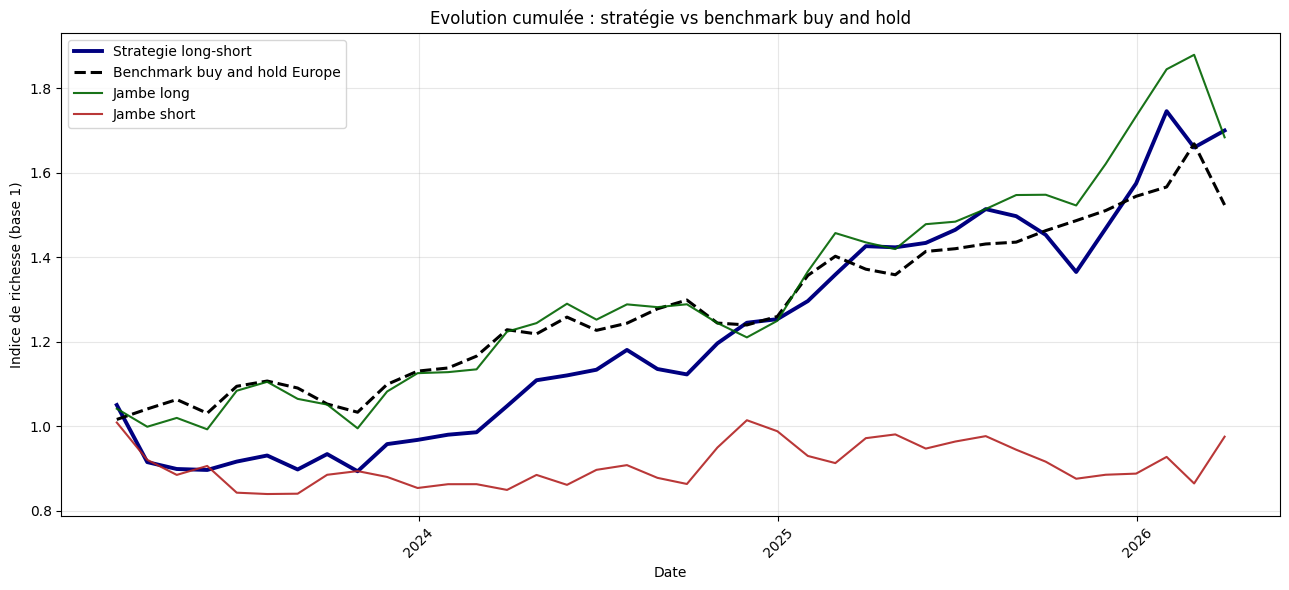

In [26]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(performances["date_performance"], performances["wealth_strategie"], label="Strategie long-short", color="navy", linewidth=2.8)
ax.plot(performances["date_performance"], performances["wealth_buy_hold"], label="Benchmark buy and hold Europe", color="black", linewidth=2.2, linestyle="--")
ax.plot(performances["date_performance"], performances["wealth_long"], label="Jambe long", color="darkgreen", linewidth=1.5, alpha=0.9)
ax.plot(performances["date_performance"], performances["wealth_short"], label="Jambe short", color="firebrick", linewidth=1.5, alpha=0.9)
ax.set_title("Evolution cumulée : stratégie vs benchmark buy and hold")
ax.set_xlabel("Date")
ax.set_ylabel("Indice de richesse (base 1)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

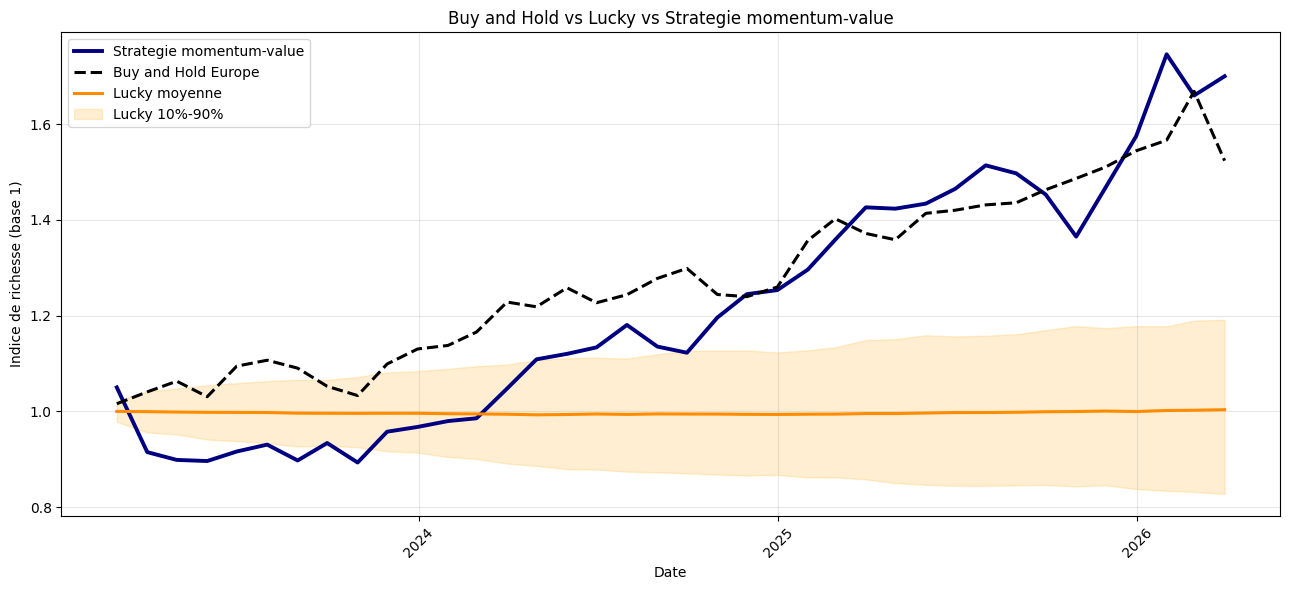

In [27]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    performances["date_performance"],
    performances["wealth_strategie"],
    label="Strategie momentum-value",
    color="navy",
    linewidth=2.8,
)
ax.plot(
    performances["date_performance"],
    performances["wealth_buy_hold"],
    label="Buy and Hold Europe",
    color="black",
    linestyle="--",
    linewidth=2.2,
)
ax.plot(
    performances["date_performance"],
    performances["wealth_lucky_moyenne"],
    label="Lucky moyenne",
    color="darkorange",
    linewidth=2.2,
)
ax.fill_between(
    performances["date_performance"],
    performances["wealth_lucky_pct10"],
    performances["wealth_lucky_pct90"],
    color="orange",
    alpha=0.18,
    label="Lucky 10%-90%",
)
ax.set_title("Buy and Hold vs Lucky vs Strategie momentum-value")
ax.set_xlabel("Date")
ax.set_ylabel("Indice de richesse (base 1)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

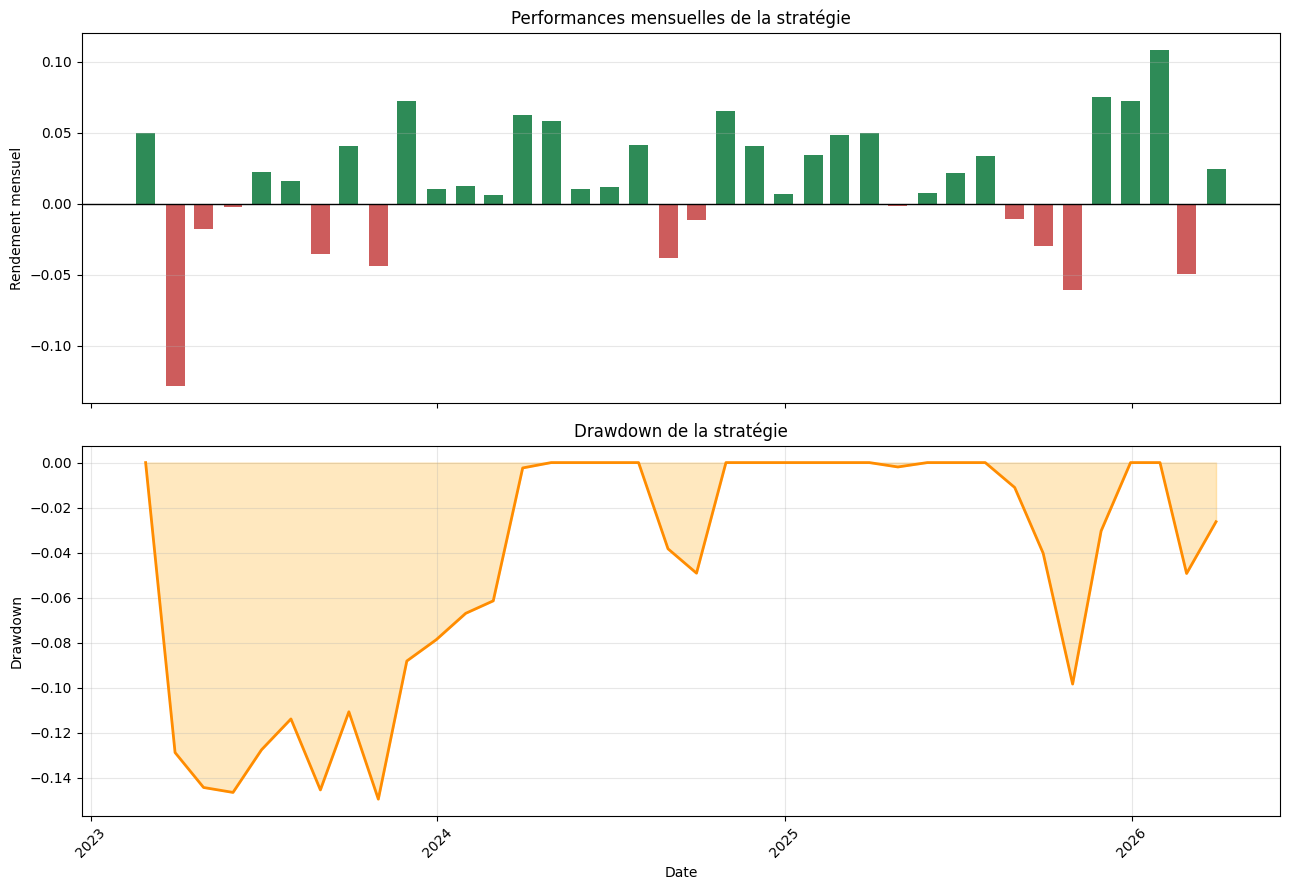

In [28]:
couleurs = np.where(performances["performance_strategie"] >= 0, "seagreen", "indianred")

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
axes[0].bar(performances["date_performance"], performances["performance_strategie"], color=couleurs, width=20)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Performances mensuelles de la stratégie")
axes[0].set_ylabel("Rendement mensuel")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].plot(performances["date_performance"], performances["drawdown_strategie"], color="darkorange", linewidth=2)
axes[1].fill_between(performances["date_performance"], performances["drawdown_strategie"], 0, color="orange", alpha=0.25)
axes[1].set_title("Drawdown de la stratégie")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

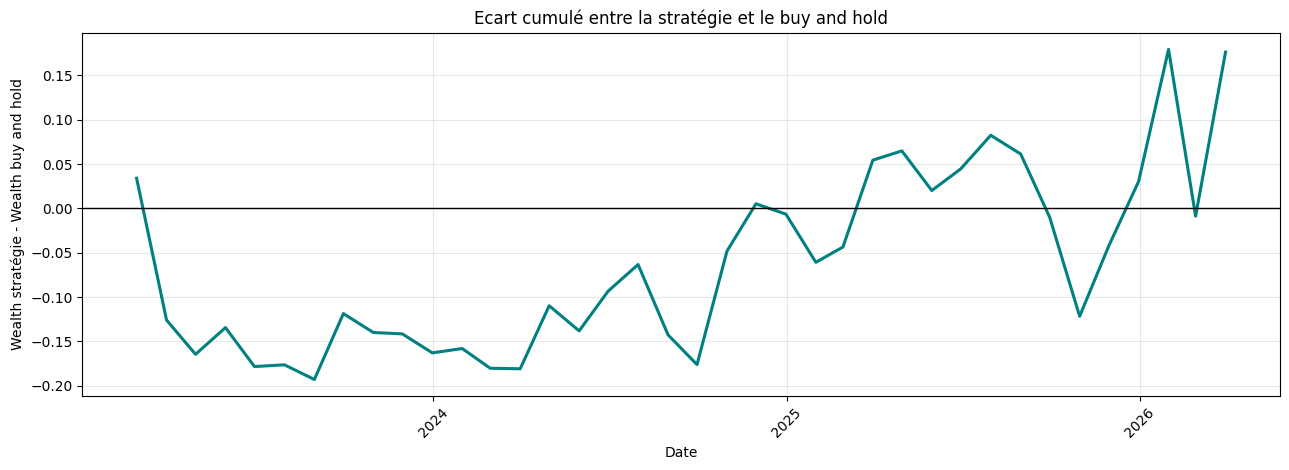

In [29]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(performances["date_performance"], performances["ecart_vs_buy_hold"], color="teal", linewidth=2.2)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Ecart cumulé entre la stratégie et le buy and hold")
ax.set_xlabel("Date")
ax.set_ylabel("Wealth stratégie - Wealth buy and hold")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

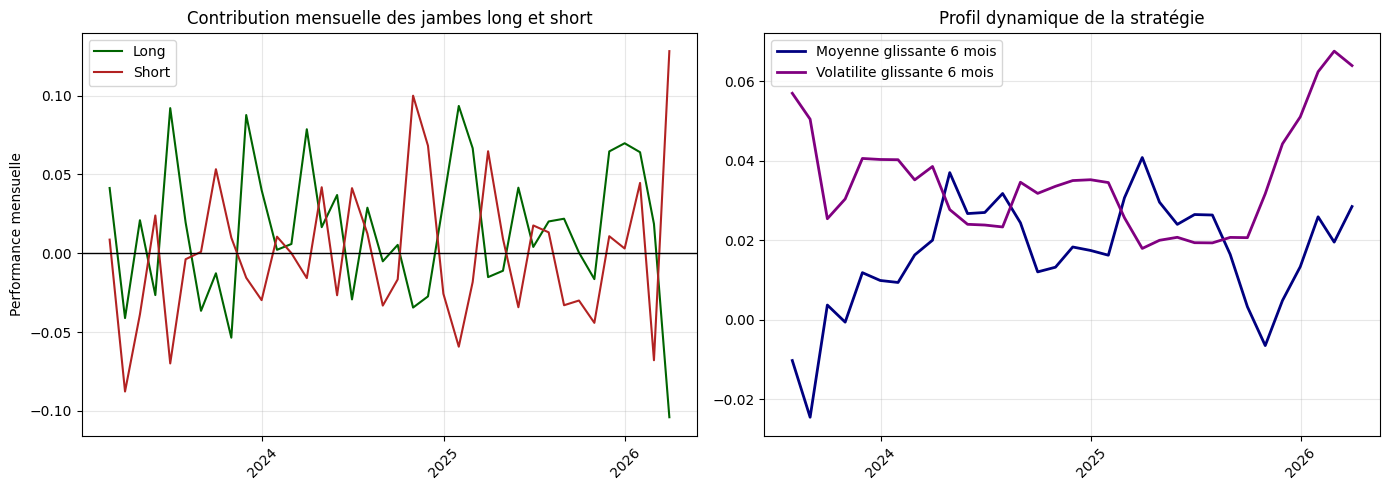

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(performances["date_performance"], performances["performance_long"], label="Long", color="darkgreen", linewidth=1.5)
axes[0].plot(performances["date_performance"], performances["performance_short"], label="Short", color="firebrick", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Contribution mensuelle des jambes long et short")
axes[0].set_ylabel("Performance mensuelle")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(performances["date_performance"], performances["rolling_mean_6m"], label="Moyenne glissante 6 mois", color="navy", linewidth=2)
axes[1].plot(performances["date_performance"], performances["rolling_vol_6m"], label="Volatilite glissante 6 mois", color="purple", linewidth=2)
axes[1].set_title("Profil dynamique de la stratégie")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for label in axes[0].get_xticklabels() + axes[1].get_xticklabels():
    label.set_rotation(45)
plt.tight_layout()
plt.show()

## 2. Distribution des rendements

Cette partie permet d'apprécier le profil de dispersion de la stratégie : asymétrie, fréquence des mois positifs et concentration éventuelle des rendements.

C:\Users\Bryce\AppData\Local\Temp\ipykernel_1328\4214112689.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


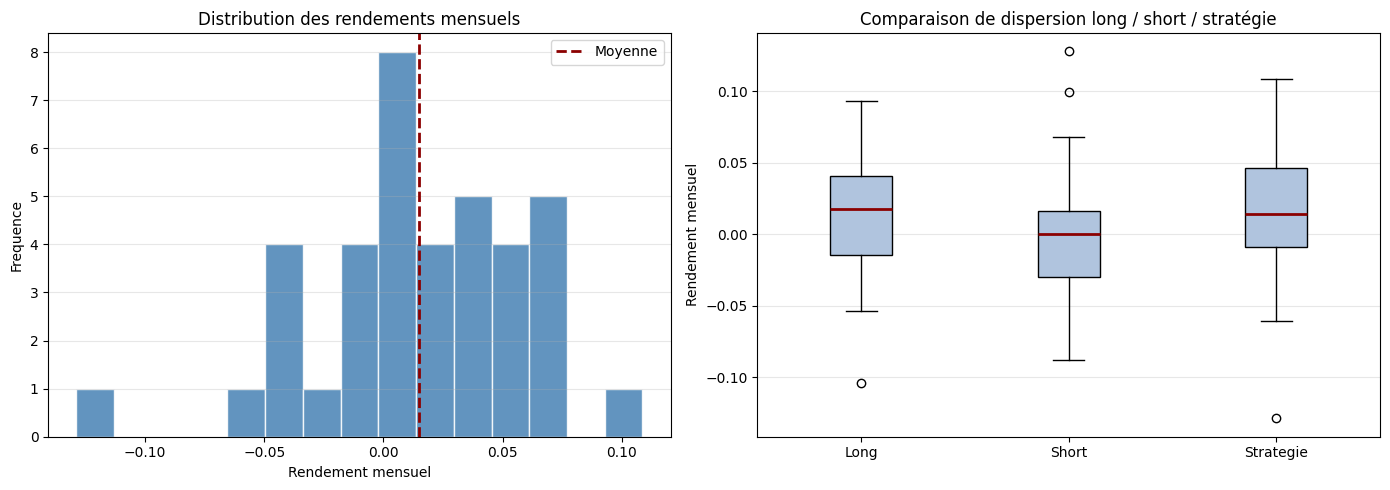

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(performances["performance_strategie"], bins=15, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(performances["performance_strategie"].mean(), color="darkred", linestyle="--", linewidth=2, label="Moyenne")
axes[0].set_title("Distribution des rendements mensuels")
axes[0].set_xlabel("Rendement mensuel")
axes[0].set_ylabel("Frequence")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

axes[1].boxplot(
    [performances["performance_long"].dropna(), performances["performance_short"].dropna(), performances["performance_strategie"].dropna()],
    labels=["Long", "Short", "Strategie"],
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="darkred", linewidth=2),
)
axes[1].set_title("Comparaison de dispersion long / short / stratégie")
axes[1].set_ylabel("Rendement mensuel")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Comparaison avec les stratégies aléatoires "lucky"

C'est la partie la plus importante pour juger la pertinence de la stratégie. On compare la stratégie réelle à la distribution de nombreuses stratégies aléatoires construites avec les mêmes contraintes.

In [32]:
display(evaluation_lucky)
display(statistiques_strategie)

,metrique,strategie,lucky_moyenne,lucky_mediane,lucky_pct05,lucky_pct95,percentile_strategie
0,performance_moyenne_mensuelle,0.015080,0.000085,0.000174,-0.006255,0.006515,1.000
1,volatilite_mensuelle,0.044948,0.022602,0.022623,0.018141,0.027422,0.000
2,performance_annualisee,0.196751,0.001972,0.002092,-0.072532,0.081042,1.000
3,volatilite_annualisee,0.155704,0.078294,0.078368,0.062843,0.094994,0.000
4,sharpe_annualise,1.263624,0.020996,0.026364,-0.949189,1.090653,0.972
5,performance_cumulee,0.699920,0.003468,-0.004776,-0.219317,0.269035,1.000
6,taux_mois_positifs,0.684211,0.500711,0.500000,0.368421,0.631579,0.992
7,max_drawdown,-0.149419,-0.140292,-0.128278,-0.254561,-0.060986,0.619


,nb_mois,performance_moyenne_mensuelle,volatilite_mensuelle,performance_annualisee,volatilite_annualisee,sharpe_annualise,performance_cumulee,taux_mois_positifs,max_drawdown
0,38,0.01508,0.044948,0.196751,0.155704,1.263624,0.69992,0.684211,-0.149419


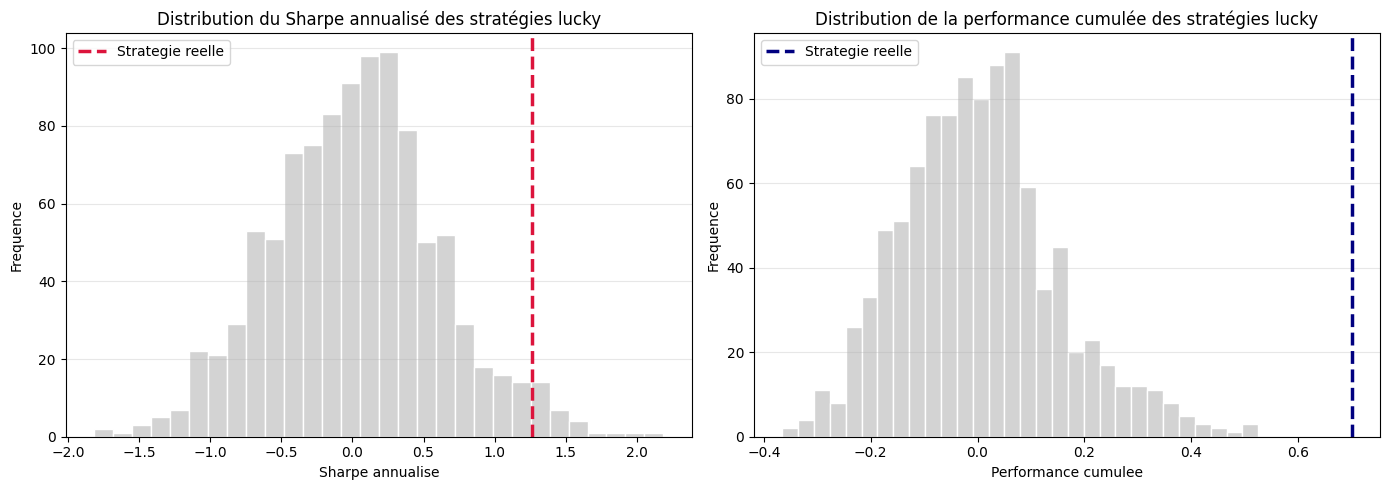

In [33]:
sharpe_strategie = float(statistiques_strategie["sharpe_annualise"].iloc[0])
perf_cumulee_strategie = float(statistiques_strategie["performance_cumulee"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lucky_stats["sharpe_annualise"].dropna(), bins=30, color="lightgray", edgecolor="white")
axes[0].axvline(sharpe_strategie, color="crimson", linestyle="--", linewidth=2.5, label="Strategie reelle")
axes[0].set_title("Distribution du Sharpe annualisé des stratégies lucky")
axes[0].set_xlabel("Sharpe annualise")
axes[0].set_ylabel("Frequence")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

axes[1].hist(lucky_stats["performance_cumulee"].dropna(), bins=30, color="lightgray", edgecolor="white")
axes[1].axvline(perf_cumulee_strategie, color="navy", linestyle="--", linewidth=2.5, label="Strategie reelle")
axes[1].set_title("Distribution de la performance cumulée des stratégies lucky")
axes[1].set_xlabel("Performance cumulee")
axes[1].set_ylabel("Frequence")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

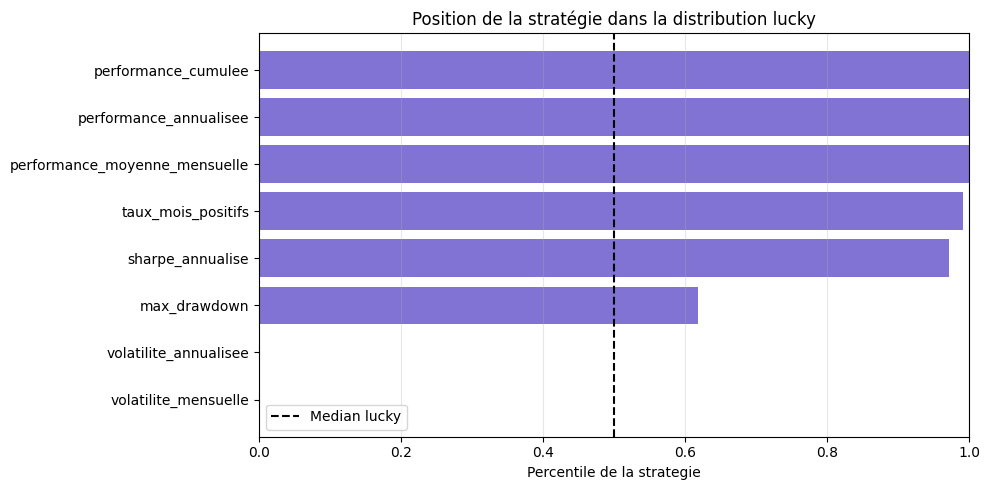

In [34]:
evaluation_plot = evaluation_lucky.copy()
evaluation_plot = evaluation_plot.sort_values("percentile_strategie", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(evaluation_plot["metrique"], evaluation_plot["percentile_strategie"], color="slateblue", alpha=0.85)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Median lucky")
ax.set_title("Position de la stratégie dans la distribution lucky")
ax.set_xlabel("Percentile de la strategie")
ax.set_xlim(0, 1)
ax.grid(True, axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Composition des portefeuilles

On termine par une lecture plus micro : quelles actions ressortent le plus souvent et comment se répartissent les pondérations.

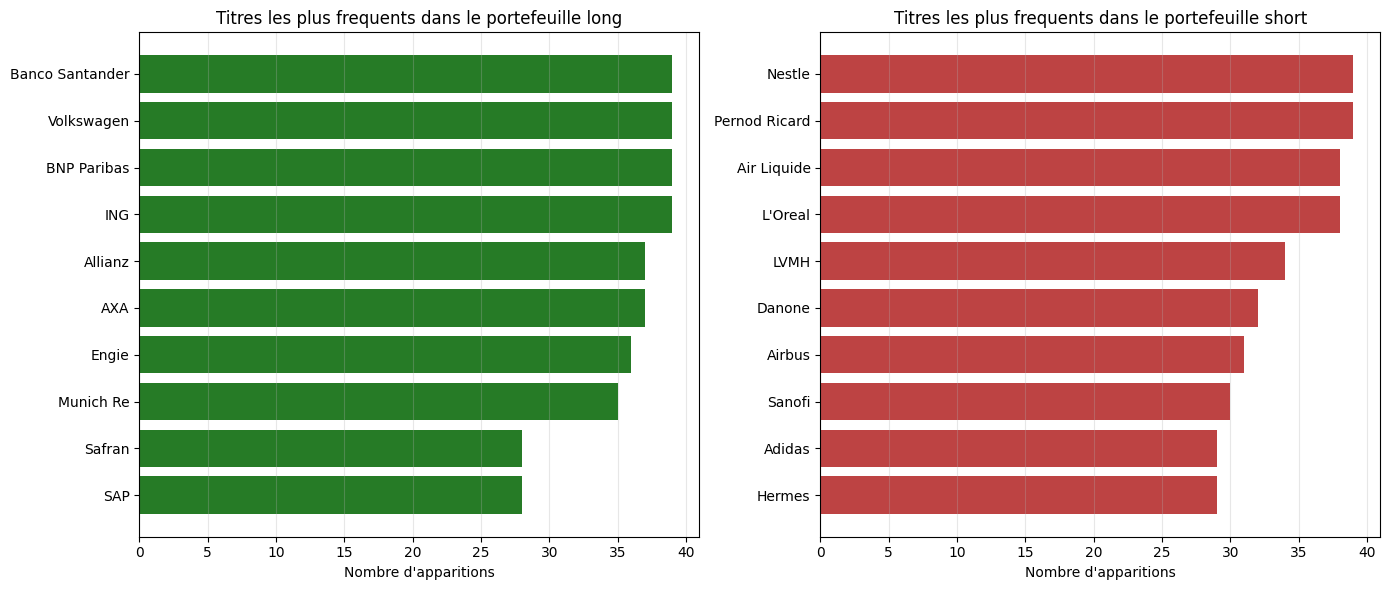

In [35]:
top_long = (
    selection.loc[selection["side"] == "long", "company_name"]
    .value_counts()
    .head(10)
    .sort_values()
)
top_short = (
    selection.loc[selection["side"] == "short", "company_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_long.index, top_long.values, color="darkgreen", alpha=0.85)
axes[0].set_title("Titres les plus frequents dans le portefeuille long")
axes[0].set_xlabel("Nombre d'apparitions")
axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(top_short.index, top_short.values, color="firebrick", alpha=0.85)
axes[1].set_title("Titres les plus frequents dans le portefeuille short")
axes[1].set_xlabel("Nombre d'apparitions")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

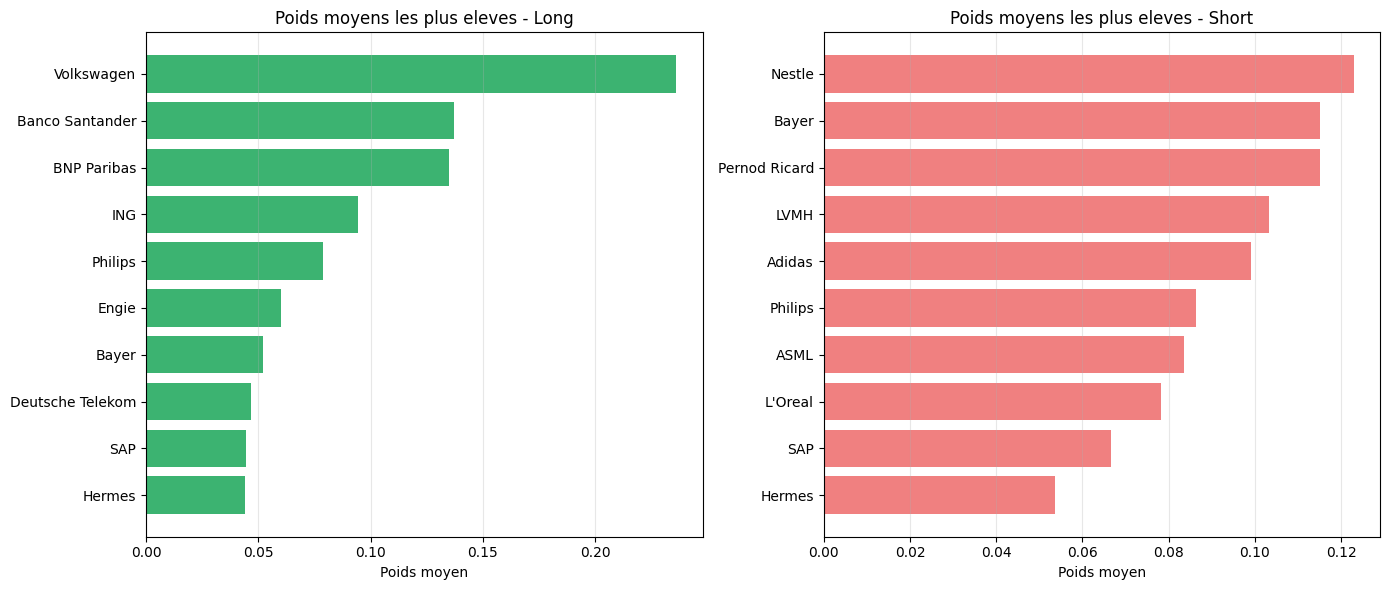

In [36]:
ponderations_moyennes = (
    ponderations.groupby(["company_name", "side"])["poids_absolu"]
    .mean()
    .reset_index()
)
ponderations_long_moy = ponderations_moyennes.loc[ponderations_moyennes["side"] == "long"].nlargest(10, "poids_absolu").sort_values("poids_absolu")
ponderations_short_moy = ponderations_moyennes.loc[ponderations_moyennes["side"] == "short"].nlargest(10, "poids_absolu").sort_values("poids_absolu")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(ponderations_long_moy["company_name"], ponderations_long_moy["poids_absolu"], color="mediumseagreen")
axes[0].set_title("Poids moyens les plus eleves - Long")
axes[0].set_xlabel("Poids moyen")
axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(ponderations_short_moy["company_name"], ponderations_short_moy["poids_absolu"], color="lightcoral")
axes[1].set_title("Poids moyens les plus eleves - Short")
axes[1].set_xlabel("Poids moyen")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion de la data analyse

Cette trame permet de commenter proprement les résultats du projet :

- la trajectoire cumulée montre si la stratégie crée réellement de la valeur ;
- l'analyse de distribution permet de juger la stabilité des rendements ;
- la comparaison avec les stratégies lucky permet de tester si la performance semble due à une vraie information plutôt qu'au hasard ;
- l'analyse de composition aide à comprendre quels titres portent le plus souvent les signaux.
